# Peti domaci zadatak - Ucenje podsticanjem

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

np.random.seed(42)

## Okruezenje
<img src="simulator.png" width="600">

In [2]:
class Simulator:
    def __init__(self):
        self.valid_states = {
            (0, 0), (0, 1), (0, 2), (0, 3), (0,4),
            (1, 0),         (1, 2),         (1, 4)
        }
        
        self.terminal_states = {
            (1, 0):-1,
            (1, 2):-1,
            (1, 4):3
        }
        
        self.start_state = (0, 0)
        self.current_state = self.start_state
        
        self.actions = [0, 1, 2, 3]
        self.action_names = ['gore', 'dole', 'levo', 'desno']
        
        self.intended_prob = 0.7
        self.other_prob = 0.1
        
    def step(self, action):
        if np.random.random() > self.intended_prob:
            action = np.random.choice([a for a in self.actions if a != action])
            
        row, col = self.current_state
        if action == 0:
            next_state = (row-1, col)
        elif action == 1:
            next_state = (row+1, col)
        elif action == 2:
            next_state = (row, col-1)
        elif action == 3:
            next_state = (row, col+1)
        else:
            next_state = self.current_state
            
        if next_state not in self.valid_states:
            next_state = self.current_state
            
        self.current_state = next_state
        
        if self.current_state in self.terminal_states:
            end = True
            reward = self.terminal_states[self.current_state]
        else:
            end = False
            reward = 0
            
        return reward, self.current_state, end
    
    def reset(self):
        self.current_state = self.start_state
        return self.current_state
    
    def get_all_states(self):
        return list(self.valid_states)
    
    def is_terminal(self, state):
        return state in self.terminal_states
    
    def print_state(self, state):
        row, col = state
        w = ord('A')
        return f'{chr(w + row)}{col + 1}'

## Q-ucenje

In [3]:
class QLearning:
    def __init__(self, simulator, epsilon, gamma=0.9, const_alpha=0.1, alpha_type='variable'):
        self.simulator = simulator
        self.gamma = gamma
        self.epsilon = epsilon
        self.alpha_type = alpha_type
        self.const_alpha = const_alpha
        
        self.V = []
        self.rewards = []
        
        self.Q_table = defaultdict(lambda: np.zeros(len(simulator.actions)))
        
    def get_alpha(self, ep):
        return np.log(ep + 1) / (ep + 1) if self.alpha_type == 'variable' else self.const_alpha
    
    def choose_action(self, state, explore=True):
        if explore and np.random.random() < self.epsilon:
            return np.random.choice(self.simulator.actions)
        else:
            return np.argmax(self.Q_table[state])
    
    def train(self, eps=3000):
        for ep in range(eps):
            state = self.simulator.reset()
            reward_ep = 0
            alpha = self.get_alpha(ep)
            
            while True:
                action = self.choose_action(state)
                R, next_state, end = self.simulator.step(action)
                reward_ep += R
                
                if end:
                    q = R
                else:
                    q = R + self.gamma * np.max(self.Q_table[next_state])
                
                self.Q_table[state][action] += alpha * (q - self.Q_table[state][action])
                
                if end:
                    break
                
                state = next_state
                
            self.rewards.append(reward_ep)
            
            V_ep = {}
            for state in self.simulator.get_all_states():
                if not self.simulator.is_terminal(state):
                    V_ep[state] = np.max(self.Q_table[state])
            
            self.V.append(V_ep)
            
    def test_policy(self, eps=10):
        rewards = []
        for _ in range(eps):
            state = self.simulator.reset()
            reward_ep = 0
            
            steps = 0
            max_steps = 100
            while steps < max_steps:
                action = self.choose_action(state, False)
                R, next_state, end = self.simulator.step(action)
                reward_ep += R
                steps += 1
                
                if end:
                    break
                
                state = next_state
                
            rewards.append(reward_ep)
            
        return np.mean(rewards)
    
    def get_policy(self):
        policy = {}
        for state in self.simulator.get_all_states():
            if not self.simulator.is_terminal(state):
                policy[state] = np.argmax(self.Q_table[state])
                
        return policy

## REINFORCE

In [4]:
class REINFORCE:
    def __init__(self, simulator, gamma=0.9, const_alpha=0.01, alpha_type='variable'):
        self.simulator = simulator
        self.gamma = gamma
        self.const_alpha = const_alpha
        self.alpha_type = alpha_type
        
        self.theta = defaultdict(lambda: np.zeros(len(simulator.actions)))
        
        self.reward_history = []
        self.theta_history = []
        
    def get_alpha(self, ep):
        return 0.1 * np.log(ep + 1) / (ep + 1) if self.alpha_type == 'variable' else self.const_alpha
    
    def get_action_probs(self, state):
        exp = np.exp(self.theta[state])
        return exp / np.sum(exp)
    
    def choose_action(self, state):
        return np.random.choice(self.simulator.actions, p=self.get_action_probs(state))
    
    def generate_episode(self):
        episode = []
        state = self.simulator.reset()
        
        while True:
            action = self.choose_action(state)
            r, next_state, end = self.simulator.step(action)
            episode.append((state, action, r))
            
            if end:
                break
            
            state = next_state
            
        return episode
    
    def train(self, eps=5000, eval=50):
        for ep in range(eps):
            episode = self.generate_episode()
            alpha = self.get_alpha(ep)
            
            # zarada
            G = 0
            v = []
            for t in range(len(episode) - 1, -1, -1):
                G = episode[t][2] + self.gamma * G
                v.insert(0, G)
            
            # reinforce update
            for t, (state, action, reward) in enumerate(episode):
                probs = self.get_action_probs(state)
                
                for a in self.simulator.actions:
                    if a == action:
                        grad = 1 - probs[a]
                    else:
                        grad = -probs[a]
                        
                    self.theta[state][a] += alpha * grad * v[t]
                    
            # evaluacija
            if ep % eval == 0:
                self.reward_history.append(self.test_curr_policy())
                
                theta_ret = {}
                for state in self.simulator.get_all_states():
                    if not self.simulator.is_terminal(state):
                        theta_ret[state] = self.theta[state].copy()
                self.theta_history.append(theta_ret)
                
    def test_curr_policy(self, eps=10):
        rewards = []
        for _ in range(eps):
            state = self.simulator.reset()
            reward_ep = 0
            
            steps = 0
            max_steps = 100
            while steps < max_steps:
                action = self.choose_action(state)
                R, next_state, end = self.simulator.step(action)
                reward_ep += R
                steps += 1
                
                if end:
                    break
                
                state = next_state
                
            rewards.append(reward_ep)
        
        return np.mean(rewards)
    
    def get_policy(self):
        policy = {}
        for state in self.simulator.get_all_states():
            if not self.simulator.is_terminal(state):
                policy[state] = np.argmax(self.theta[state])
                
        return policy

## Rezultati

### Q-ucenje

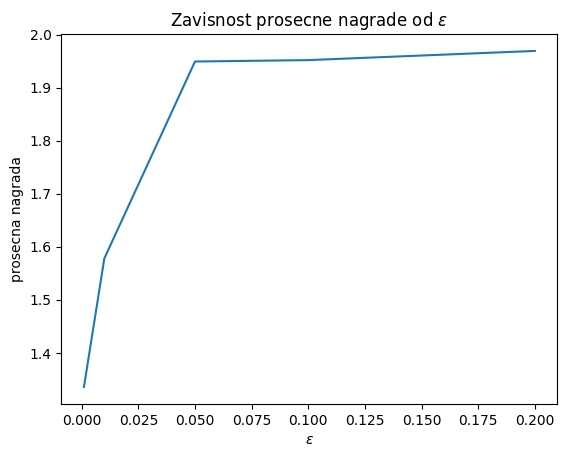

In [5]:
simulator = Simulator()

epsilons = np.array([0.01, 0.05, 0.1, 0.2])
epsilons = np.array([0.001, 0.01, 0.05, 0.1, 0.2])
reward_eps = []

for epsilon in epsilons:
    simulator = Simulator()
    q_learn = QLearning(simulator, epsilon)
    q_learn.train(eps=3000)
    reward_eps.append(q_learn.test_policy(eps=3000))
    
plt.figure()
plt.plot(epsilons, reward_eps)
plt.title('Zavisnost prosecne nagrade od $\epsilon$')
plt.xlabel('$\epsilon$')
plt.ylabel('prosecna nagrada')
plt.show()

In [6]:
best_epsilon = epsilons[np.argmax(reward_eps)]
print(f'Eksperimentalno izabrano epsilon = {best_epsilon}')

Eksperimentalno izabrano epsilon = 0.2


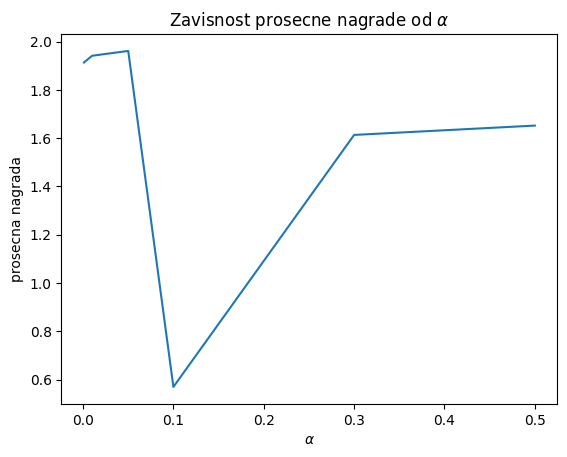

In [7]:
alphas = np.array([0.001, 0.01, 0.05, 0.1, 0.3, 0.5])
reward_a = []

for alpha in alphas:
    simulator = Simulator()
    q_learn = QLearning(simulator, epsilon=best_epsilon, const_alpha=alpha, alpha_type='const')
    q_learn.train(eps=3000)
    reward_a.append(q_learn.test_policy(eps=3000))
    
plt.figure()
plt.plot(alphas, reward_a)
plt.title(r'Zavisnost prosecne nagrade od $\alpha$')
plt.xlabel(r'$\alpha$')
plt.ylabel('prosecna nagrada')
plt.show()

In [8]:
best_alpha = alphas[np.argmax(reward_a)]
print(f'Eksperimentalno izabrano const alpha = {best_alpha}')

Eksperimentalno izabrano const alpha = 0.05


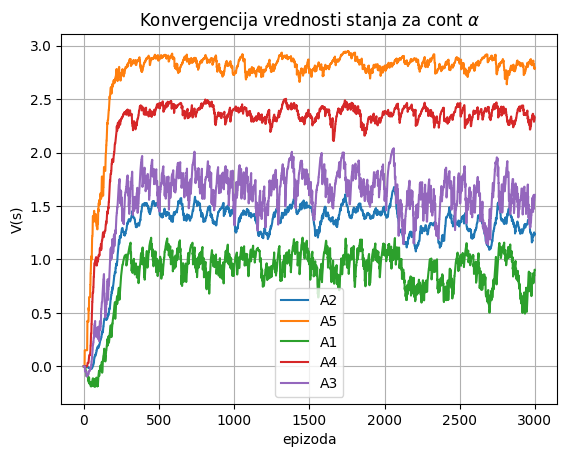

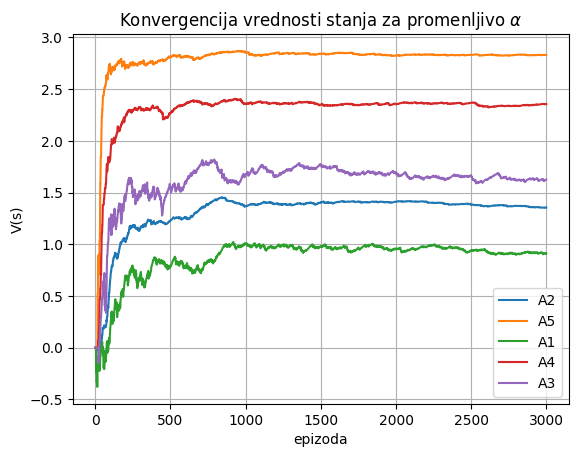

A1 -> desno
A2 -> desno
A3 -> desno
A4 -> desno
A5 -> dole


In [9]:
### const alpha
eps = 3000
simulator = Simulator()
q_learn = QLearning(simulator, epsilon=best_epsilon, const_alpha=best_alpha, alpha_type='const')
q_learn.train(eps=eps)

plt.figure()

for state in q_learn.simulator.get_all_states():
    if not q_learn.simulator.is_terminal(state):
        values = [V_ep[state] for V_ep in q_learn.V]
        plt.plot(values, label=simulator.print_state(state))

plt.xlabel('epizoda')
plt.ylabel('V(s)')
plt.title(rf'Konvergencija vrednosti stanja za cont $\alpha$')
plt.legend()
plt.grid(True)
plt.show()

### promanljivo alpha
simulator = Simulator()
q_learn = QLearning(simulator, epsilon=best_epsilon)
q_learn.train(eps=eps)

plt.figure()

for state in q_learn.simulator.get_all_states():
    if not q_learn.simulator.is_terminal(state):
        values = [V_ep[state] for V_ep in q_learn.V]
        plt.plot(values, label=simulator.print_state(state))

plt.xlabel('epizoda')
plt.ylabel('V(s)')
plt.title(rf'Konvergencija vrednosti stanja za promenljivo $\alpha$')
plt.legend()
plt.grid(True)
plt.show()

policy = q_learn.get_policy()
for state in sorted(policy.keys()):
    print(simulator.print_state(state), '->',
          simulator.action_names[policy[state]])

Konstantna $\alpha$ konvergira brže, ali sa većom varijansom, dok promenljivo $\alpha$ daje stabilnije krive posle konvergencije zbog postepenog smanjenja konstante ucenja.

Prosecna nagrada za gama = 0.9: 2.2


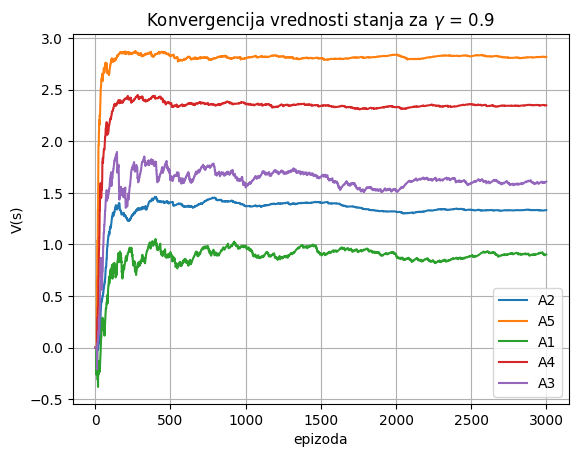

Prosecna nagrada za gama = 0.999: 1.8


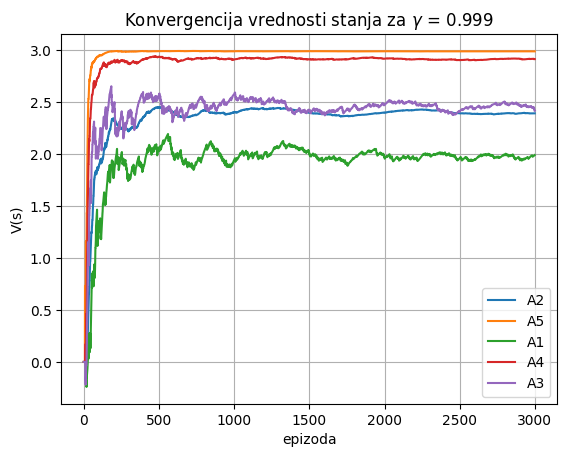

In [10]:
### gama = 0.9
simulator = Simulator()
q_learn = QLearning(simulator, epsilon=best_epsilon)
q_learn.train(eps=eps)
print(f'Prosecna nagrada za gama = 0.9: {q_learn.test_policy()}')

plt.figure()

for state in q_learn.simulator.get_all_states():
    if not q_learn.simulator.is_terminal(state):
        values = [V_ep[state] for V_ep in q_learn.V]
        plt.plot(values, label=simulator.print_state(state))

plt.xlabel('epizoda')
plt.ylabel('V(s)')
plt.title(rf'Konvergencija vrednosti stanja za $\gamma$ = 0.9')
plt.legend()
plt.grid(True)
plt.show()

### gama = 0.999
simulator = Simulator()
q_learn = QLearning(simulator, epsilon=best_epsilon, gamma=0.999)
q_learn.train(eps=eps)
print(f'Prosecna nagrada za gama = 0.999: {q_learn.test_policy()}')

plt.figure()

for state in q_learn.simulator.get_all_states():
    if not q_learn.simulator.is_terminal(state):
        values = [V_ep[state] for V_ep in q_learn.V]
        plt.plot(values, label=simulator.print_state(state))

plt.xlabel('epizoda')
plt.ylabel('V(s)')
plt.title(rf'Konvergencija vrednosti stanja za $\gamma$ = 0.999')
plt.legend()
plt.grid(True)
plt.show()

Za $\gamma=0.999$ V-vrednosti su više zbog većeg vrednovanja budućih nagrada, ali finalna politika je lošija (1.8 vs 2.2 prosečna nagrada) jer previsoko $\gamma$ usporava konvergenciju i čini agenta preosetljivim na stohastičku prirodu okruženja.

### REINFORCE

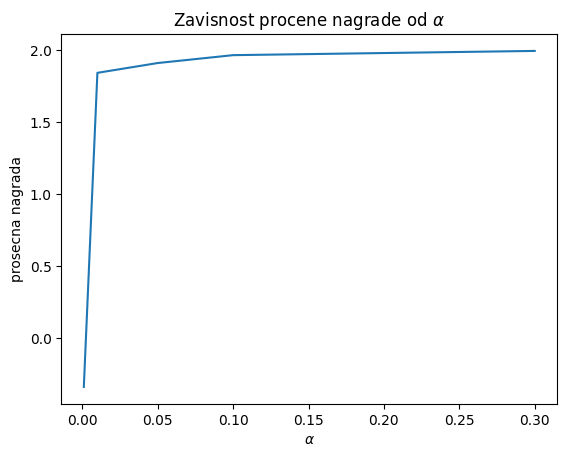

In [11]:
alphas = np.array([0.001, 0.01, 0.05, 0.1, 0.3])
rewards = []

eps = 3000

for alpha in alphas:
    simulator = Simulator()
    rl = REINFORCE(simulator, const_alpha=alpha, alpha_type='const')
    rl.train(eps)
    rewards.append(rl.test_curr_policy(eps))
    
plt.figure()
plt.plot(alphas, rewards)
plt.title(rf'Zavisnost procene nagrade od $\alpha$')
plt.xlabel(rf'$\alpha$')
plt.ylabel('prosecna nagrada')
plt.show()

In [12]:
best_alpha = alphas[np.argmax(rewards)]
print(f'Eksperimentalno izabrano const alpha = {best_alpha}')

Eksperimentalno izabrano const alpha = 0.3


In [13]:
def plot_theta_for_state(agent, state):
    nA = len(agent.simulator.actions)
    thetas = [[] for _ in range(nA)]
    
    for hist in agent.theta_history:
        if state in hist:
            for a in range(nA):
                thetas[a].append(hist[state][a])
        else:
            for a in range(nA):
                thetas[a].append(np.nan)

    x = np.arange(len(agent.theta_history))
    x = np.arange(0, 3000, 50)

    plt.figure()
    for a in range(nA):
        plt.plot(x, thetas[a], label=f'{agent.simulator.action_names[a]}')
        
    plt.title(f'Parametri za stanje {agent.simulator.print_state(state)}')
    plt.xlabel('evaluation step')
    plt.ylabel(rf'$\theta$')
    plt.legend()
    plt.show()

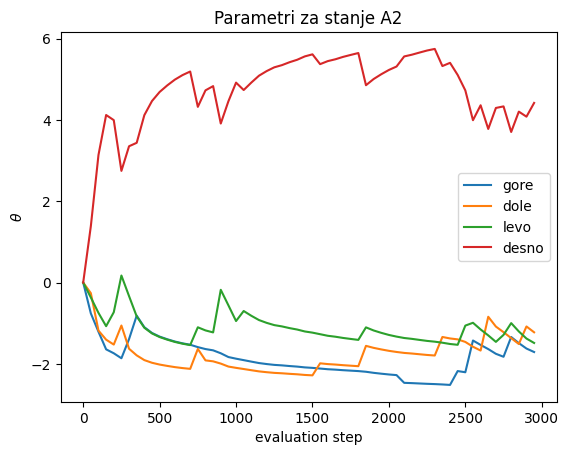

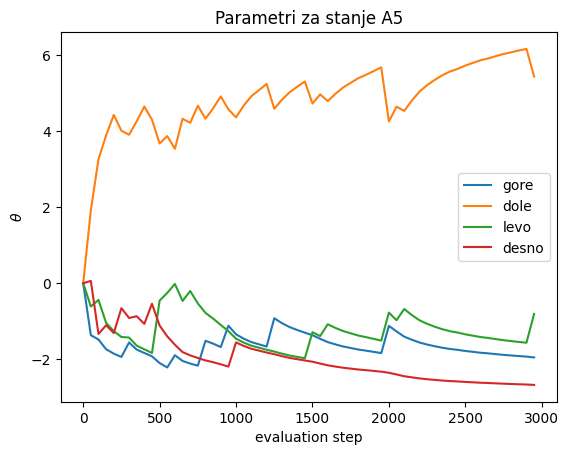

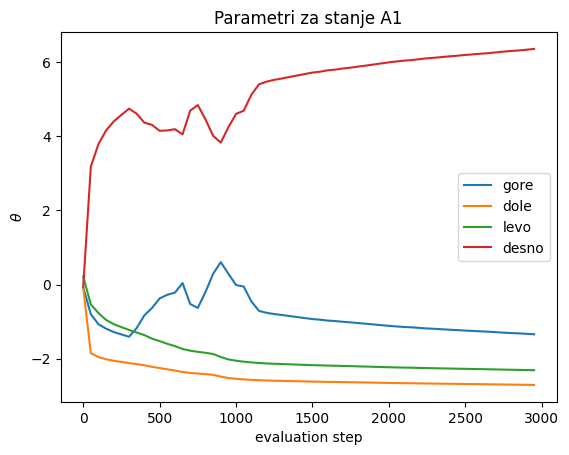

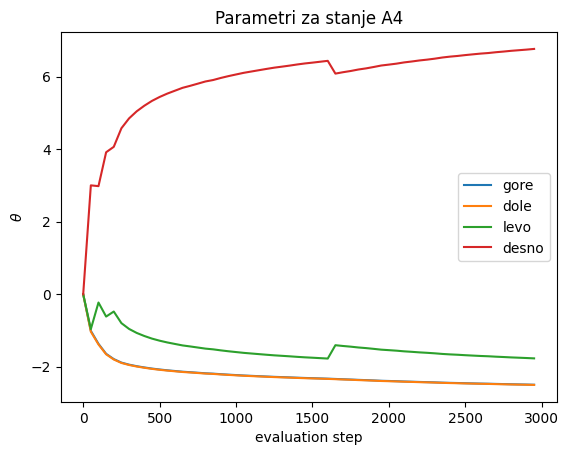

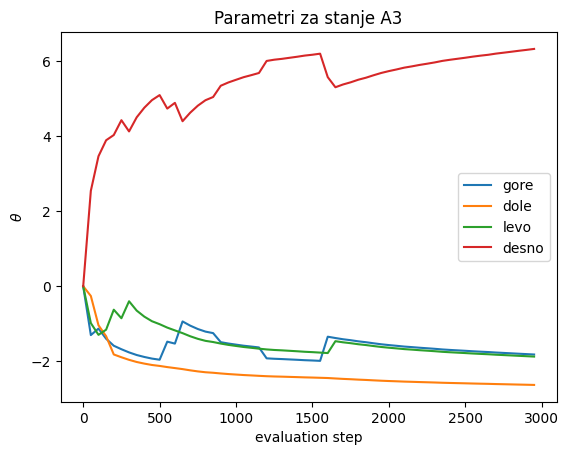

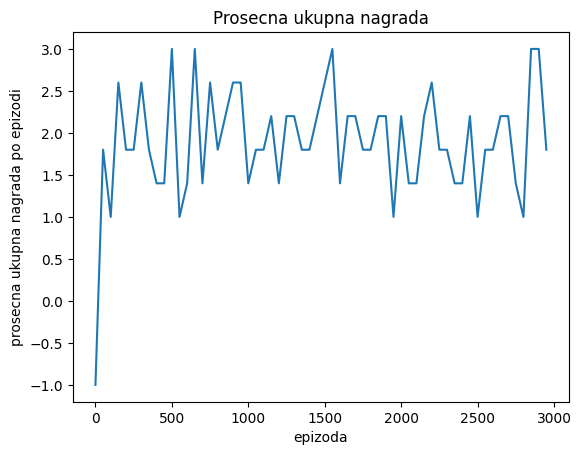

A1 -> desno
A2 -> desno
A3 -> desno
A4 -> desno
A5 -> dole


In [14]:
simulator = Simulator()
rl = REINFORCE(simulator, const_alpha=best_alpha, alpha_type='const')
rl.train(eps)
    
for s in rl.simulator.get_all_states():
    if not rl.simulator.is_terminal(s):
        plot_theta_for_state(rl, s)
        
plt.figure()
plt.plot(np.arange(0, 3000, 50), rl.reward_history)
plt.title('Prosecna ukupna nagrada')
plt.xlabel('epizoda')
plt.ylabel('prosecna ukupna nagrada po epizodi')
plt.show()

policy = rl.get_policy()
for state in sorted(policy.keys()):
    print(simulator.print_state(state), '->',
          simulator.action_names[policy[state]])